# QWEN Models
Objective: Demonstrate a small and large pre-trained model's performance on our dataset with fine-tuning

Stretch goal: Update <i>all</i> model parameters and not just the classification head

In [24]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from IPython.display import clear_output
import warnings
import json

# Filter UserWarning
warnings.filterwarnings("ignore", category=UserWarning)

import torch
import torch.optim as optim
from torch import Tensor
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

import sys
sys.path.append("../utils")
from evaluate_models import plot_confusion_matrix, print_evaluation_report, evaluate_model, SP_GREEN, SP_RED
from custom_datasets import DialogueDataset
from focal_loss import FocalLoss

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


## Small Model - 0.6B Parameters

### Data Load and Dataset Creation

In [3]:
train_data = pd.read_parquet('../01 - Inputs/train_data_labels_as_numbers.parquet')
val_data = pd.read_parquet('../01 - Inputs/val_data_labels_as_numbers.parquet')
test_data = pd.read_parquet('../01 - Inputs/test_data_labels_as_numbers.parquet')

Since the goal is only to perform a Linear Probe, we can pre-compute the QWEN embeddings for train, validation, and test and save to disk.

Doing so will massively speed up performance and is theoretically sound since the QWEN parameters will not be updated anyway

In [4]:
class QwenDataset(Dataset):
    def __init__(self,
                 input_text: list[str],
                 labels: list[int],
                 tokenizer: AutoTokenizer,
                 max_length: int,
                 embedding_model: AutoModel,
                 device: str = 'cpu'):
        # Set attributes
        self.input_text = input_text
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.device = device

        # Process the text in chunks of 50 to get the embeddings
        self.embeddings = self.embed_text(embedding_model)

    def embed_text(self, embedding_model: AutoModel = None) -> Tensor:
        # Iterate through the text as a list
        all_embeddings = []
        for i in tqdm(range(0, len(self.input_text), 50)):
            chunk = self.input_text[i:i+50] # Current data
            tokenized_chunk = self.tokenizer(
                chunk,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt",
            ).to(self.device)
            with torch.inference_mode():
                outputs = embedding_model(**tokenized_chunk)
                embeddings = self.last_token_pool(outputs.last_hidden_state, tokenized_chunk['attention_mask'])
            del tokenized_chunk, outputs
            all_embeddings.append(embeddings.cpu())
        return torch.cat(all_embeddings, dim=0)

    @staticmethod
    def last_token_pool(last_hidden_states: Tensor,
                        attention_mask: Tensor) -> Tensor:
        """
        Pools the last hidden states of the QWEN model by taking the hidden state of the last non-padded token in each sequence.
        This is how QWEN is trained and the function is taken directly from the Huggingface example
        """
        left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
        if left_padding:
            return last_hidden_states[:, -1]
        else:
            sequence_lengths = attention_mask.sum(dim=1) - 1
            batch_size = last_hidden_states.shape[0]
            return last_hidden_states[torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths]

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]


In [5]:
# Load the tokenizer - Qwen specified a padding side of 'left' in their example code, so we do the same here
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-Embedding-0.6B', padding_side='left')

In [6]:
# Set the max length for tokenization based on the longest line observed in the datasets, with a buffer of 25%
max_length = int(max(train_data['Line'].str.len().max(), test_data['Line'].str.len().max(), val_data['Line'].str.len().max()) * 1.25)
print(f"Max length for tokenization: {max_length}")

Max length for tokenization: 1952


In [7]:
# Download the model and move it to the device (GPU if available)
qwen_small = AutoModel.from_pretrained('Qwen/Qwen3-Embedding-0.6B').to(device)

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 949.55it/s, Materializing param=norm.weight]                              


In [8]:
# Create the dataset and dataloader for the training, validation, and testing data
small_train_dataset = QwenDataset(
    input_text=train_data['Line'].tolist(),
    labels=train_data['Character'].tolist(),
    tokenizer=tokenizer,
    max_length=max_length,
    embedding_model=qwen_small,
    device=device
)
print("Train Embeddings Complete")

small_val_dataset = QwenDataset(
    input_text=val_data['Line'].tolist(),
    labels=val_data['Character'].tolist(),
    tokenizer=tokenizer,
    max_length=max_length,
    embedding_model=qwen_small,
    device=device
)
print("Validation Embeddings Complete")

small_test_dataset = QwenDataset(
    input_text=test_data['Line'].tolist(),
    labels=test_data['Character'].tolist(),
    tokenizer=tokenizer,
    max_length=max_length,
    embedding_model=qwen_small,
    device=device
)
print("Test Embeddings Complete")

100%|██████████| 564/564 [02:42<00:00,  3.47it/s]


Train Embeddings Complete


100%|██████████| 121/121 [00:40<00:00,  3.01it/s]


Validation Embeddings Complete


100%|██████████| 121/121 [00:38<00:00,  3.14it/s]

Test Embeddings Complete


In [9]:
# Clean up GPU memory after embedding
with torch.no_grad():
    torch.cuda.empty_cache()
del qwen_small

In [10]:
# Create the dataloaders
small_train_dataloader = DataLoader(small_train_dataset, batch_size = 128) # We can afford larger batches since embeddings are precalculated
small_val_dataloader = DataLoader(small_val_dataset, batch_size = 128)
small_test_dataloader = DataLoader(small_test_dataset, batch_size = 128)

Design the classification head

In [11]:
class LinearProbeClassificationHead(nn.Module):
    def __init__(self, input_embedding_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_embedding_size, num_classes)

    def forward(self, x):
        # Cast x to float
        x = x.float()
        return self.linear(x)

In [12]:
# Extract the embedding size and initialize the linear probe classification head
input_size = small_train_dataset.embeddings.shape[1] # Tensor is shape (n records, embedding_size)
num_classes = len(train_data['Character'].unique())
linear_probe = LinearProbeClassificationHead(input_size, num_classes)

In [25]:
### Training the Linear Probe
def train_linear_probe(model, train_loader, val_loader, num_epochs, lr, weight_decay,
                       class_weights, warmup_ratio, patience=10, device = 'cpu', loss_type = 'cross_entropy'):
    """
    Fine-tune the output layer with best practices, not updating the embeddings.

    Args:
        model: LinearProbeClassificationHead model
        train_loader: Training data loader
        val_loader: Validation data loader
        num_epochs: Maximum number of epochs
        lr: Learning rate
        weight_decay: L2 regularization strength
        class_weights: Class weights for imbalanced data
        warmup_ratio: Ratio of training for warmup
        patience: Early stopping patience

    Returns:
        Dictionary with model, history, and metrics
    """
    model.to(device)

    # Loss function with class weights
    if loss_type == 'cross_entropy':
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    elif loss_type == 'focal_loss':
        criterion = FocalLoss(task_type = 'multi-class', num_classes=len(class_weights))

    # AdamW optimizer (recommended for transformers)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Calculate total training steps
    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)

    # Linear warmup + decay scheduler
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    print(f"Training setup:")
    print(f"  Total steps: {total_steps:,}")
    print(f"  Warmup steps: {warmup_steps:,} ({warmup_ratio*100:.0f}%)")
    print(f"  Steps per epoch: {len(train_loader):,}")

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_preds, train_labels_list = [], []

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch in train_pbar:
            x = batch[0].to(device) # Embeddings
            labels = torch.tensor(batch[1]).to(device) # Labels

            # Forward pass
            optimizer.zero_grad()
            outputs = model(x=x)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()

            optimizer.step()
            scheduler.step()  # Update learning rate

            # Track metrics
            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels_list.extend(labels.cpu().numpy())

            # Update progress bar
            current_lr = scheduler.get_last_lr()[0]
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})

        train_loss /= len(train_loader)
        train_acc = accuracy_score(train_labels_list, train_preds)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds, val_labels_list = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                inputs = batch[0].to(device)
                labels = torch.tensor(batch[1]).to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = accuracy_score(val_labels_list, val_preds)

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(scheduler.get_last_lr()[0])

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f} Val Acc={val_acc:.4f} | LR={scheduler.get_last_lr()[0]:.2e}")

        # Early stopping
        if val_loss <= best_val_loss * 0.995:  # Consider it an improvement if val_loss decreases by at least 0.5%
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  -> New best model (val_loss: {val_loss:.4f})")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Load best model
    model.load_state_dict(best_model_state)

    return {'model': model, 'history': history, 'best_val_loss': best_val_loss}


In [14]:
class_weights = compute_class_weight('balanced', classes=np.arange(len(set(small_train_dataset.labels))), y=small_train_dataset.labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
class_weights


tensor([0.1364, 0.1860, 0.1983, 0.5028, 0.5031, 1.2196, 1.4968, 1.5143, 1.7273,
        1.9168, 2.0236, 2.0372, 2.2490, 2.3119, 2.3661, 2.3723, 3.1880, 3.4945,
        3.7390, 4.2064, 4.2260, 4.3061, 4.4979, 4.6356, 4.6594, 4.6834, 5.0198,
        5.4082, 5.9384, 6.1391, 6.2232], device='cuda:0')

In [15]:
results_small = train_linear_probe(
    model=linear_probe,
    train_loader=small_train_dataloader,
    val_loader=small_val_dataloader,
    num_epochs=50,
    lr=2e-5,
    weight_decay=1e-4,
    class_weights=class_weights,
    warmup_ratio=0.1,
    patience=5,
    device=device
)
clear_output()

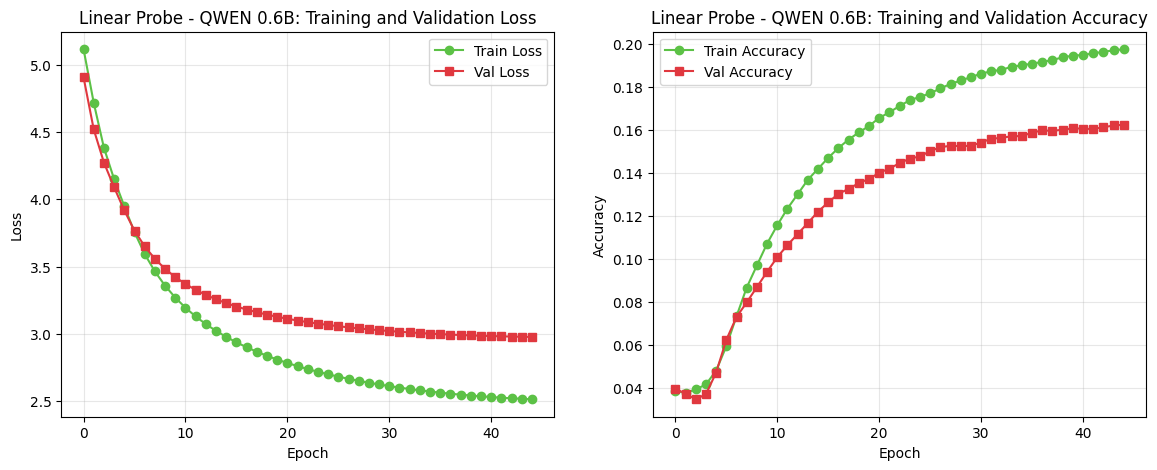

In [22]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(results_small['history']['train_loss'], label='Train Loss', marker='o', color = SP_GREEN)
axes[0].plot(results_small['history']['val_loss'], label='Val Loss', marker='s', color = SP_RED)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Linear Probe - QWEN 0.6B: Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(results_small['history']['train_acc'], label='Train Accuracy', marker='o', color = SP_GREEN)
axes[1].plot(results_small['history']['val_acc'], label='Val Accuracy', marker='s', color = SP_RED)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Linear Probe - QWEN 0.6B: Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


Model Evaluation

In [17]:
def evaluate_linear_probe(model, loader):
    """Evaluate LinearProbe on QWEN model on a dataset."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.inference_mode():
        for batch in tqdm(loader, desc="Evaluating"):
            inputs = batch[0].to(device)
            labels = torch.tensor(batch[1]).to(device)

            outputs = model(x=inputs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1_score': f1_score(all_labels, all_preds, average='macro', zero_division=0)
    }

    return metrics, all_preds, all_labels


# Evaluate on test set
test_metrics, test_preds, test_labels_list = evaluate_linear_probe(results_small['model'], small_test_dataloader)
clear_output()
print_evaluation_report(test_metrics, "Linear Probe on QWEN 0.6B - Test Set")


Linear Probe on QWEN 0.6B - Test Set Evaluation Results
Accuracy:  0.1766
Precision: 0.1542 (macro)
Recall:    0.2528 (macro)
F1-Score:  0.1557 (macro)



In [18]:
with open('../01 - Inputs/label_to_char.json', 'r') as f:
    label_to_char = json.load(f)

c:\repos\Project_SP\.venv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\repos\Project_SP\.venv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


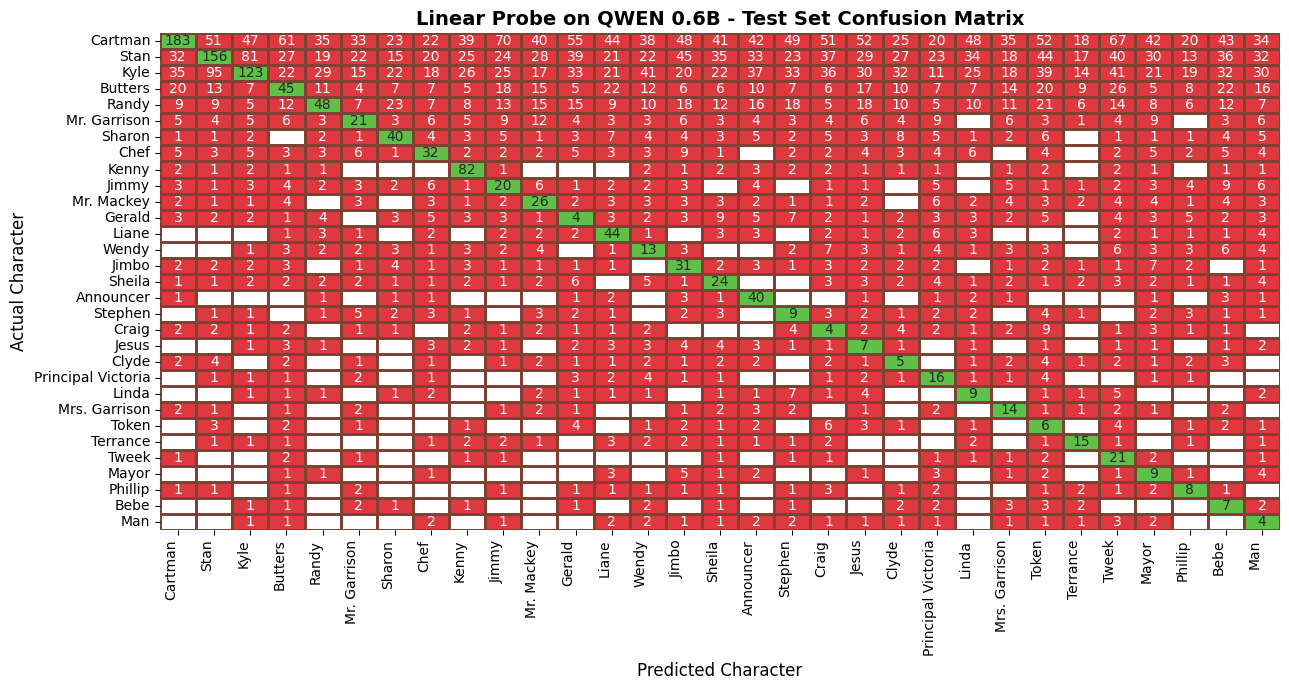

In [19]:
# Convert numeric labels back to character names for the confusion matrix
test_labels_named = [label_to_char[str(label)] for label in test_labels_list]
test_preds_named = [label_to_char[str(pred)] for pred in test_preds]

# Plot confusion matrix
plot_confusion_matrix(test_labels_named, test_preds_named, title="Linear Probe on QWEN 0.6B - Test Set Confusion Matrix",
                      save_path="../05 - Outputs/qwen_06B__confusion_matrix.png",
                      figsize=(13, 7))

### Testing with Focal Loss instead of Cross-Entropy Loss

In [26]:
results_small_focal = train_linear_probe(
    model=linear_probe,
    train_loader=small_train_dataloader,
    val_loader=small_val_dataloader,
    num_epochs=50,
    lr=2e-5,
    weight_decay=1e-4,
    class_weights=class_weights,
    warmup_ratio=0.1,
    patience=5,
    device=device,
    loss_type='focal_loss'
)
clear_output()

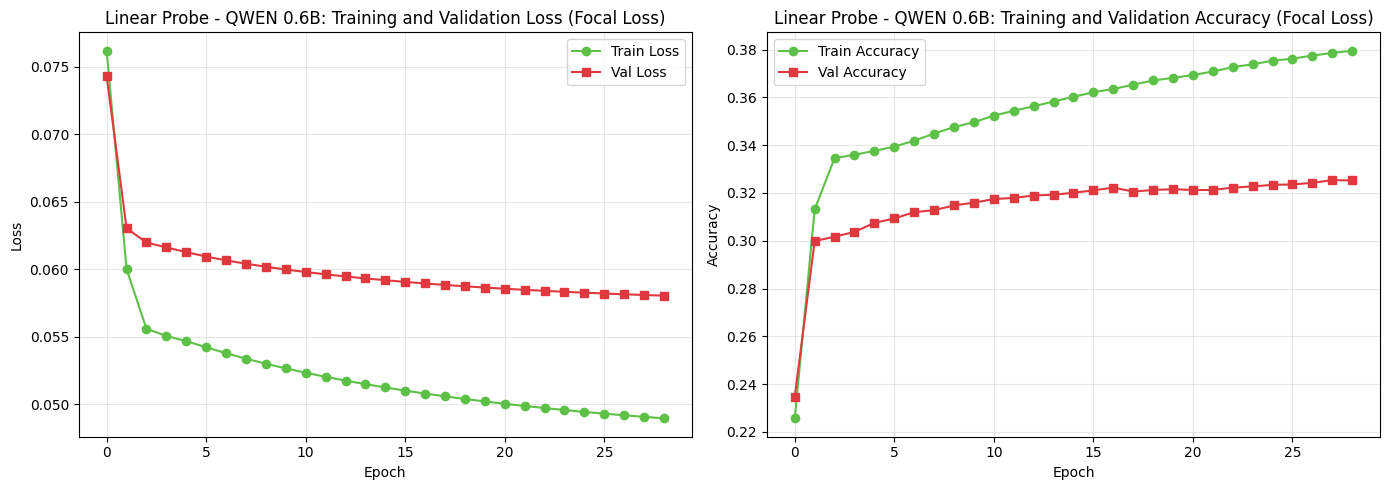

In [27]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(results_small_focal['history']['train_loss'], label='Train Loss', marker='o', color = SP_GREEN)
axes[0].plot(results_small_focal['history']['val_loss'], label='Val Loss', marker='s', color = SP_RED)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Linear Probe - QWEN 0.6B: Training and Validation Loss (Focal Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(results_small_focal['history']['train_acc'], label='Train Accuracy', marker='o', color = SP_GREEN)
axes[1].plot(results_small_focal['history']['val_acc'], label='Val Accuracy', marker='s', color = SP_RED)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Linear Probe - QWEN 0.6B: Training and Validation Accuracy (Focal Loss)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Evaluate on test set
test_metrics_focal, test_preds_focal, test_labels_list_focal = evaluate_linear_probe(results_small_focal['model'], small_test_dataloader)
clear_output()
print_evaluation_report(test_metrics_focal, "Linear Probe on QWEN 0.6B - Test Set (Focal Loss)")


Linear Probe on QWEN 0.6B - Test Set (Focal Loss) Evaluation Results
Accuracy:  0.3343
Precision: 0.3227 (macro)
Recall:    0.1824 (macro)
F1-Score:  0.2158 (macro)



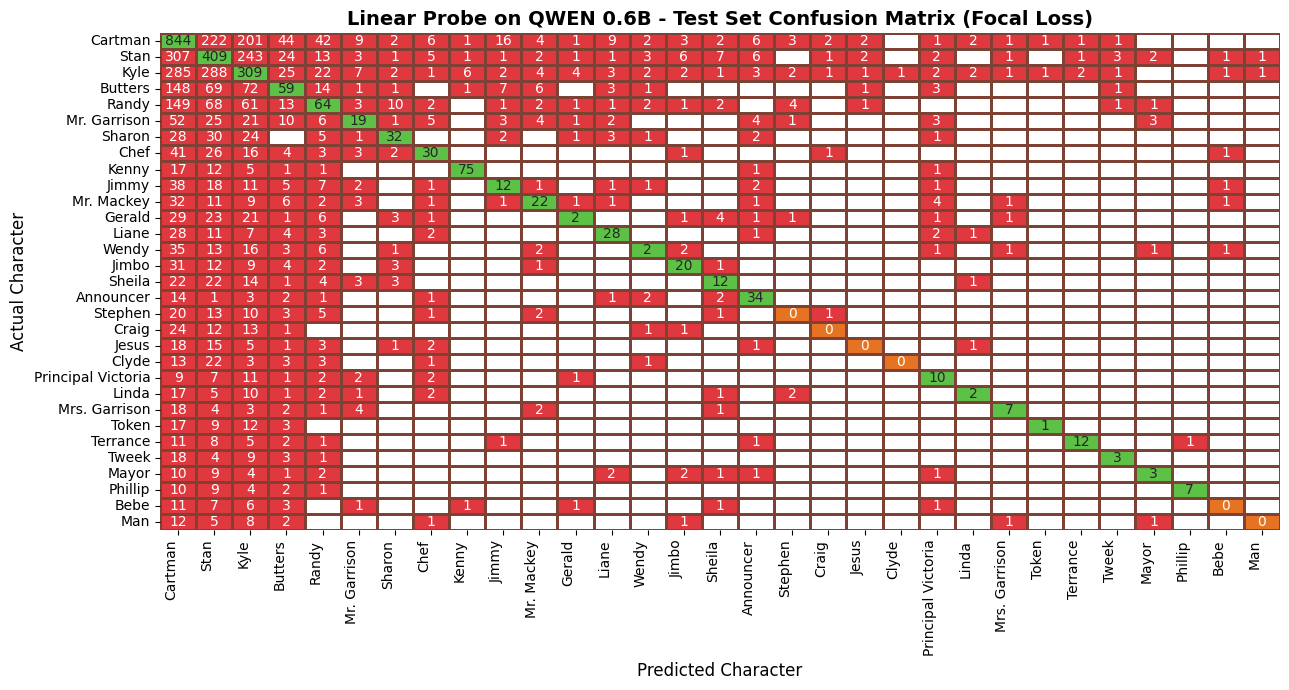

In [29]:
# Convert numeric labels back to character names for the confusion matrix
test_labels_named = [label_to_char[str(label)] for label in test_labels_list_focal]
test_preds_named = [label_to_char[str(pred)] for pred in test_preds_focal]

# Plot confusion matrix
plot_confusion_matrix(test_labels_named, test_preds_named, title="Linear Probe on QWEN 0.6B - Test Set Confusion Matrix (Focal Loss)",
                      save_path="../05 - Outputs/qwen_06B__confusion_matrix_focal_loss.png",
                      figsize=(13, 7))

# Form Final Outputs DataFrame

In [30]:
all_metrics = pd.DataFrame([test_metrics, test_metrics_focal], index=["Fine-Tuned (Linear Probe) on QWEN 0.6B", "Fine-Tuned (Linear Probe) on QWEN 0.6B (Focal Loss)"])
all_metrics.to_csv("../05 - Outputs/qwen_metrics_comparison.csv")